<a href="https://colab.research.google.com/github/Keshabbu/Datascience/blob/main/Exercise_09_Forecasting__Clustering_%26_XAI_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Science Exercise: Time Series Imputation with XGBoost for Clustering and Business Insights

## Context

A retail energy provider monitors **daily electricity consumption** of commercial customers. Due to sensor failures, parts of the time series contain missing values. The company wants to:

1. Impute missing consumption values using **time series forecasting with XGBoost**.
2. Cluster customers based on their consumption behavior.
3. Use **Explainable AI (XAI)** to interpret both the forecasting and clustering results for business decisions.

You will work with **real-life data** from:

> UCI Electricity Load Diagrams 2011–2014 dataset (individual household/industry electricity consumption in kWh).

Dataset link: [https://archive.ics.uci.edu/ml/datasets/ElectricityLoadDiagrams20112014](https://archive.ics.uci.edu/ml/datasets/ElectricityLoadDiagrams20112014)

---

## Learning Objectives

* Apply XGBoost for time series forecasting.
* Perform data imputation for missing values.
* Cluster customers using engineered features.
* Apply XAI techniques (SHAP, PDP) for business interpretation.
* Translate technical insights into business recommendations.

---

## Business Case

The company wants to design **custom energy pricing plans** for commercial customers based on consumption patterns. However, missing data makes segmentation unreliable. Your task is to produce a trustworthy segmentation and explain the drivers behind consumption behavior.

---

## Part 1 – Data Preparation

1. Load the dataset and select 50 customers (columns).
2. Visualize missingness patterns.

---

## Part 2 – Feature Engineering for XGBoost

Convert each time series into supervised format:

* Lag features: t-1, t-2, t-7, t-14
* Rolling means: 7-day, 14-day

---

## Part 3 – Time Series Forecasting with XGBoost

For each customer:

1. Train an XGBoost regressor on available data only.
2. Predict missing timestamps.
4. Replace missing values with predictions.

---

## Part 4 – Clustering After Imputation

From the completed time series, extract clustering features:

* Mean consumption
* Std deviation
* Peak-to-average ratio
* Weekday vs weekend ratio
* Seasonal amplitude

Apply:

* Standardization
* KMeans

Choose optimal k using silhouette score.

---

## Part 5 – Explainable AI for Forecasting

Use SHAP for XGBoost:

1. Global SHAP summary plot
2. Feature importance per customer
3. Dependence plots for lag features

**Questions:**

* Which lags matter most?
* Are weekly patterns more important than daily ones?
* How do calendar effects influence predictions?

---

## Part 6 – Explainable AI for Clustering

Explain clusters using:

* Cluster centroids
* SHAP on a surrogate classifier predicting cluster labels
* Feature contribution comparison across clusters

---

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving household_electricity.csv to household_electricity.csv


In [ ]:
# =====================
# 0. Imports
# =====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import seaborn as sns

from sklearn.metrics import root_mean_squared_error, silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb
import shap

In [ ]:
df = pd.read_csv("household_electricity.csv", sep=";", decimal=",", parse_dates=[0], index_col=0)


In [ ]:
df.head()

,MT_328,MT_034,MT_016,MT_315,MT_058,MT_240,MT_077,MT_120,MT_306,MT_127,...,MT_250,MT_298,MT_031,MT_220,MT_110,MT_125,MT_091,MT_057,MT_006,MT_046
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
2011-01-01,66992.592593,0.0,0.0,6802.850925,0.0,29327.951807,0.0,0.0,3519.439633,0.0,...,NaN,89983.058824,0.0,123417.721519,0.0,0.0,0.0,NaN,0.0,0.0
2011-01-02,NaN,0.0,0.0,8285.908596,0.0,40733.710843,0.0,0.0,8444.579725,NaN,...,8688.207120,146514.823529,0.0,283379.746835,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-03,126733.333333,0.0,0.0,8274.472252,0.0,NaN,0.0,0.0,8138.777382,0.0,...,8685.003236,144561.470588,0.0,NaN,0.0,0.0,NaN,0.0,0.0,0.0
2011-01-04,129348.148148,NaN,0.0,8161.196953,0.0,39684.698795,0.0,0.0,8212.348446,NaN,...,8751.553398,136199.117647,0.0,281924.050633,0.0,0.0,0.0,0.0,NaN,NaN
2011-01-05,NaN,0.0,NaN,8333.237214,0.0,40659.807229,0.0,0.0,7612.857871,NaN,...,8793.592233,119503.588235,NaN,288379.746835,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df.index.name = "data"

In [ ]:
df

,MT_328,MT_034,MT_016,MT_315,MT_058,MT_240,MT_077,MT_120,MT_306,MT_127,...,MT_250,MT_298,MT_031,MT_220,MT_110,MT_125,MT_091,MT_057,MT_006,MT_046
data,,,,,,,,,,,,,,,,,,,,,
2011-01-01,66992.592593,0.000000,0.000000,6802.850925,0.000000,29327.951807,0.000000,0.000000,3519.439633,0.000000,...,NaN,89983.058824,0.000000,123417.721519,0.000000,0.000000,0.000000,NaN,0.000000,0.000000
2011-01-02,NaN,0.000000,0.000000,8285.908596,0.000000,40733.710843,0.000000,0.000000,8444.579725,NaN,...,8688.207120,146514.823529,0.000000,283379.746835,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2011-01-03,126733.333333,0.000000,0.000000,8274.472252,0.000000,NaN,0.000000,0.000000,8138.777382,0.000000,...,8685.003236,144561.470588,0.000000,NaN,0.000000,0.000000,NaN,0.000000,0.000000,0.000000
2011-01-04,129348.148148,NaN,0.000000,8161.196953,0.000000,39684.698795,0.000000,0.000000,8212.348446,NaN,...,8751.553398,136199.117647,0.000000,281924.050633,0.000000,0.000000,0.000000,0.000000,NaN,NaN
2011-01-05,NaN,0.000000,NaN,8333.237214,0.000000,40659.807229,0.000000,0.000000,7612.857871,NaN,...,8793.592233,119503.588235,NaN,288379.746835,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-28,105807.407407,NaN,3589.407745,7458.808487,10753.670473,32408.457831,2604.301075,3412.257727,7650.366786,NaN,...,8600.550162,78477.588235,9526.315789,257632.911392,3476.190476,4218.611521,11486.324216,1798.977853,NaN,16151.658768
2014-12-29,NaN,2127.793296,3563.781321,7153.307943,11305.057096,32850.313253,3725.268817,3775.275013,NaN,12.448133,...,7924.731392,76226.294118,10194.078947,244658.227848,1800.264550,3914.327917,10963.308873,2396.933560,22824.404762,14303.317536
2014-12-30,103200.000000,NaN,4403.758542,7228.759521,11066.884176,32852.698795,3468.279570,NaN,7311.268467,12.448133,...,7944.569579,79536.117647,10231.907895,267746.835443,NaN,4117.429838,11538.358906,NaN,23880.952381,14279.620853


In [ ]:
df_50 = df.iloc[:,:50]

In [ ]:
df_50

,MT_328,MT_034,MT_016,MT_315,MT_058,MT_240,MT_077,MT_120,MT_306,MT_127,...,MT_250,MT_298,MT_031,MT_220,MT_110,MT_125,MT_091,MT_057,MT_006,MT_046
data,,,,,,,,,,,,,,,,,,,,,
2011-01-01,66992.592593,0.000000,0.000000,6802.850925,0.000000,29327.951807,0.000000,0.000000,3519.439633,0.000000,...,NaN,89983.058824,0.000000,123417.721519,0.000000,0.000000,0.000000,NaN,0.000000,0.000000
2011-01-02,NaN,0.000000,0.000000,8285.908596,0.000000,40733.710843,0.000000,0.000000,8444.579725,NaN,...,8688.207120,146514.823529,0.000000,283379.746835,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2011-01-03,126733.333333,0.000000,0.000000,8274.472252,0.000000,NaN,0.000000,0.000000,8138.777382,0.000000,...,8685.003236,144561.470588,0.000000,NaN,0.000000,0.000000,NaN,0.000000,0.000000,0.000000
2011-01-04,129348.148148,NaN,0.000000,8161.196953,0.000000,39684.698795,0.000000,0.000000,8212.348446,NaN,...,8751.553398,136199.117647,0.000000,281924.050633,0.000000,0.000000,0.000000,0.000000,NaN,NaN
2011-01-05,NaN,0.000000,NaN,8333.237214,0.000000,40659.807229,0.000000,0.000000,7612.857871,NaN,...,8793.592233,119503.588235,NaN,288379.746835,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-28,105807.407407,NaN,3589.407745,7458.808487,10753.670473,32408.457831,2604.301075,3412.257727,7650.366786,NaN,...,8600.550162,78477.588235,9526.315789,257632.911392,3476.190476,4218.611521,11486.324216,1798.977853,NaN,16151.658768
2014-12-29,NaN,2127.793296,3563.781321,7153.307943,11305.057096,32850.313253,3725.268817,3775.275013,NaN,12.448133,...,7924.731392,76226.294118,10194.078947,244658.227848,1800.264550,3914.327917,10963.308873,2396.933560,22824.404762,14303.317536
2014-12-30,103200.000000,NaN,4403.758542,7228.759521,11066.884176,32852.698795,3468.279570,NaN,7311.268467,12.448133,...,7944.569579,79536.117647,10231.907895,267746.835443,NaN,4117.429838,11538.358906,NaN,23880.952381,14279.620853


In [ ]:
df_50.shape

(1462, 50)

In [ ]:
df_50.head()

,MT_328,MT_034,MT_016,MT_315,MT_058,MT_240,MT_077,MT_120,MT_306,MT_127,...,MT_250,MT_298,MT_031,MT_220,MT_110,MT_125,MT_091,MT_057,MT_006,MT_046
data,,,,,,,,,,,,,,,,,,,,,
2011-01-01,66992.592593,0.0,0.0,6802.850925,0.0,29327.951807,0.0,0.0,3519.439633,0.0,...,NaN,89983.058824,0.0,123417.721519,0.0,0.0,0.0,NaN,0.0,0.0
2011-01-02,NaN,0.0,0.0,8285.908596,0.0,40733.710843,0.0,0.0,8444.579725,NaN,...,8688.207120,146514.823529,0.0,283379.746835,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-03,126733.333333,0.0,0.0,8274.472252,0.0,NaN,0.0,0.0,8138.777382,0.0,...,8685.003236,144561.470588,0.0,NaN,0.0,0.0,NaN,0.0,0.0,0.0
2011-01-04,129348.148148,NaN,0.0,8161.196953,0.0,39684.698795,0.0,0.0,8212.348446,NaN,...,8751.553398,136199.117647,0.0,281924.050633,0.0,0.0,0.0,0.0,NaN,NaN
2011-01-05,NaN,0.0,NaN,8333.237214,0.0,40659.807229,0.0,0.0,7612.857871,NaN,...,8793.592233,119503.588235,NaN,288379.746835,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df_50.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1462 entries, 2011-01-01 to 2015-01-01
Data columns (total 50 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MT_328  1229 non-null   float64
 1   MT_034  1252 non-null   float64
 2   MT_016  1243 non-null   float64
 3   MT_315  1225 non-null   float64
 4   MT_058  1246 non-null   float64
 5   MT_240  1233 non-null   float64
 6   MT_077  1249 non-null   float64
 7   MT_120  1227 non-null   float64
 8   MT_306  1231 non-null   float64
 9   MT_127  1234 non-null   float64
 10  MT_234  1236 non-null   float64
 11  MT_040  1237 non-null   float64
 12  MT_154  1231 non-null   float64
 13  MT_056  1218 non-null   float64
 14  MT_156  1256 non-null   float64
 15  MT_279  1267 non-null   float64
 16  MT_001  1262 non-null   float64
 17  MT_232  1235 non-null   float64
 18  MT_335  1250 non-null   float64
 19  MT_102  1266 non-null   float64
 20  MT_010  1238 non-null   float64
 21  MT_181  1249 non-nu

In [ ]:
df_50.describe()

,MT_328,MT_034,MT_016,MT_315,MT_058,MT_240,MT_077,MT_120,MT_306,MT_127,...,MT_250,MT_298,MT_031,MT_220,MT_110,MT_125,MT_091,MT_057,MT_006,MT_046
count,1229.000000,1252.000000,1243.000000,1225.000000,1246.000000,1233.000000,1249.000000,1227.000000,1231.000000,1234.000000,...,1249.000000,1266.000000,1230.000000,1236.000000,1265.000000,1237.000000,1279.000000,1265.000000,1230.000000,1255.000000
mean,120541.560438,1008.392159,2383.878650,8526.267931,6207.692348,35002.361074,2543.568188,900.333128,7766.926988,4017.719927,...,8918.165398,92561.113001,6398.196138,283225.523330,543.842148,2749.190697,9915.291977,1755.329908,13654.991773,9465.149827
std,15920.365358,615.622111,1447.177024,1139.012426,3685.050456,3788.936863,1671.262372,1644.296328,1062.106579,4494.427802,...,882.453645,10211.341941,3900.176926,40535.363005,1110.149447,1648.020253,6015.817009,1139.057311,8162.966401,5749.060018
min,429.629630,0.000000,0.000000,45.233950,0.000000,154.915663,0.000000,0.000000,29.607743,0.000000,...,51.223301,425.294118,0.000000,1101.265823,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,108540.740741,0.000000,1248.861048,7654.379761,6301.386623,32320.578313,0.000000,0.000000,7089.737646,0.000000,...,8351.825243,86530.794118,0.000000,256018.987342,0.000000,0.000000,0.000000,0.000000,13482.142857,4715.639810
50%,118792.592593,1232.891061,2861.617312,8373.585419,7397.226754,34881.301205,2956.989247,0.000000,7614.406521,31.120332,...,8819.760518,92672.647059,7875.822368,273316.455696,0.000000,3415.066470,12407.605070,2064.735945,16248.511905,11379.146919
75%,132066.666667,1402.409218,3331.150342,9138.199129,8714.110930,37674.554217,3844.086022,0.000000,8359.921039,9346.887967,...,9445.210356,98272.000000,8819.078947,305674.050633,0.000000,3864.844904,14064.376251,2476.149915,18955.357143,12964.454976
max,162407.407407,2272.346369,5609.339408,12404.363439,12748.776509,46247.012048,5552.688172,5133.053955,11731.421294,10733.609959,...,11816.951456,146514.823529,13167.763158,419974.683544,7003.968254,5237.075332,23236.157438,5184.838160,26562.500000,21322.274882


In [ ]:
df_50.isnull().sum()


,0
MT_328,233
MT_034,210
MT_016,219
MT_315,237
MT_058,216
MT_240,229
MT_077,213
MT_120,235
MT_306,231
MT_127,228


In [ ]:
df_50.dtypes.unique()

array([dtype('float64')], dtype=object)

In [ ]:
df_50.isna().sum().sort_values(ascending=False)

,0
MT_056,244
MT_289,244
MT_138,240
MT_109,239
MT_315,237
MT_073,236
MT_120,235
MT_328,233
MT_006,232
MT_031,232


In [ ]:
df_50.head()

,MT_328,MT_034,MT_016,MT_315,MT_058,MT_240,MT_077,MT_120,MT_306,MT_127,...,MT_250,MT_298,MT_031,MT_220,MT_110,MT_125,MT_091,MT_057,MT_006,MT_046
data,,,,,,,,,,,,,,,,,,,,,
2011-01-01,66992.592593,0.0,0.0,6802.850925,0.0,29327.951807,0.0,0.0,3519.439633,0.0,...,NaN,89983.058824,0.0,123417.721519,0.0,0.0,0.0,NaN,0.0,0.0
2011-01-02,NaN,0.0,0.0,8285.908596,0.0,40733.710843,0.0,0.0,8444.579725,NaN,...,8688.207120,146514.823529,0.0,283379.746835,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-03,126733.333333,0.0,0.0,8274.472252,0.0,NaN,0.0,0.0,8138.777382,0.0,...,8685.003236,144561.470588,0.0,NaN,0.0,0.0,NaN,0.0,0.0,0.0
2011-01-04,129348.148148,NaN,0.0,8161.196953,0.0,39684.698795,0.0,0.0,8212.348446,NaN,...,8751.553398,136199.117647,0.0,281924.050633,0.0,0.0,0.0,0.0,NaN,NaN
2011-01-05,NaN,0.0,NaN,8333.237214,0.0,40659.807229,0.0,0.0,7612.857871,NaN,...,8793.592233,119503.588235,NaN,288379.746835,0.0,0.0,0.0,0.0,0.0,0.0


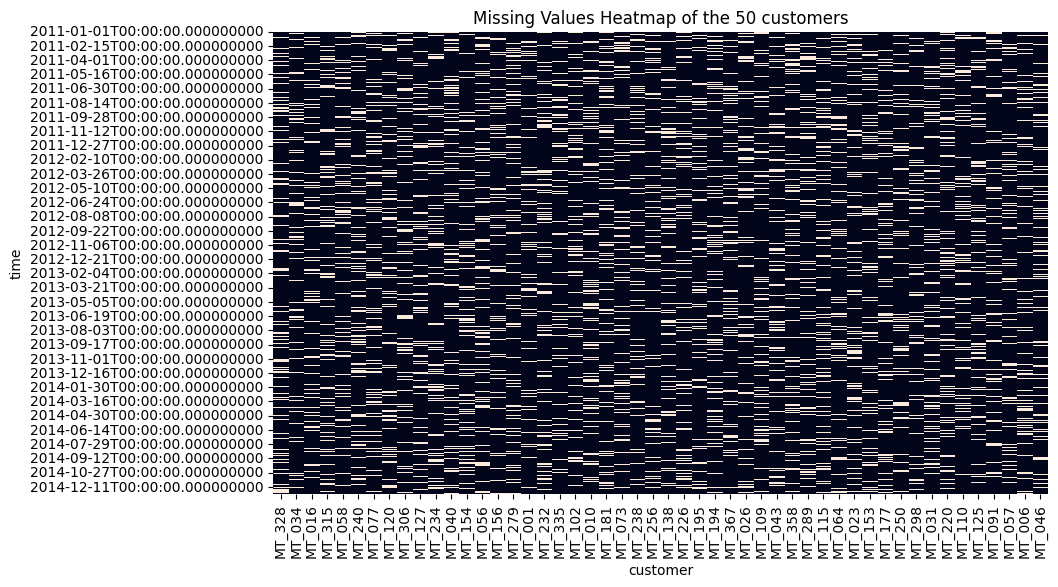

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_50.isnull(), cbar=False)
plt.title("Missing Values Heatmap of the 50 customers")
plt.xlabel("customer")
plt.ylabel("time")
plt.show()


In [ ]:
customer_id = "MT_328"
ts = df_50[customer_id]

In [ ]:
ts.head()

,MT_328
data,
2011-01-01,66992.592593
2011-01-02,NaN
2011-01-03,126733.333333
2011-01-04,129348.148148
2011-01-05,NaN


In [ ]:
ts.isna().sum()

np.int64(233)

In [ ]:
def create_time_features(series):
    df_feat = pd.DataFrame({"y": series})

    # Lag features
    df_feat["lag_1"] = series.shift(1)
    df_feat["lag_2"] = series.shift(2)
    df_feat["lag_7"] = series.shift(7)
    df_feat["lag_14"] = series.shift(14)

    # Rolling means (shifted to avoid leakage)
    df_feat["roll_mean_7"] = series.shift(1).rolling(7).mean()
    df_feat["roll_mean_14"] = series.shift(1).rolling(14).mean()

    return df_feat


In [ ]:
df_feat = create_time_features(ts)
df_feat.head(15)


,y,lag_1,lag_2,lag_7,lag_14,roll_mean_7,roll_mean_14
data,,,,,,,
2011-01-01,66992.592593,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-02,NaN,66992.592593,NaN,NaN,NaN,NaN,NaN
2011-01-03,126733.333333,NaN,66992.592593,NaN,NaN,NaN,NaN
2011-01-04,129348.148148,126733.333333,NaN,NaN,NaN,NaN,NaN
2011-01-05,NaN,129348.148148,126733.333333,NaN,NaN,NaN,NaN
2011-01-06,133488.888889,NaN,129348.148148,NaN,NaN,NaN,NaN
2011-01-07,134192.592593,133488.888889,NaN,NaN,NaN,NaN,NaN
2011-01-08,131570.370370,134192.592593,133488.888889,66992.592593,NaN,NaN,NaN
2011-01-09,128496.296296,131570.370370,134192.592593,NaN,NaN,NaN,NaN


In [ ]:
df_feat_clean = df_feat.dropna()


In [ ]:
train_data = df_feat_clean[df_feat_clean["y"].notna()]
missing_data = df_feat[df_feat["y"].isna()]


In [ ]:
train_data.shape
missing_data.shape


(233, 7)

In [ ]:
X_train = train_data.drop(columns="y")
y_train = train_data["y"]


In [ ]:
X_train.head()
X_train.describe()


,lag_1,lag_2,lag_7,lag_14,roll_mean_7,roll_mean_14
count,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000
mean,118419.296608,118643.635232,118759.103641,118271.708683,119013.925570,118756.747143
std,11187.523658,11062.470172,10709.908725,12180.309308,9059.184159,9196.021433
min,86207.407407,86207.407407,71844.444444,71844.444444,101899.470899,105237.037037
25%,111600.000000,112088.888889,114074.074074,110796.296296,112885.714286,112402.116402
50%,116985.185185,117044.444444,118192.592593,118318.518519,116725.925926,116892.063492
75%,121596.296296,123985.185185,125537.037037,124607.407407,125401.587302,125279.100529
max,158644.444444,158644.444444,154533.333333,162348.148148,144077.248677,148488.359788


In [ ]:
xgb_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)




XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
X_missing = missing_data.drop(columns="y").dropna()


In [ ]:
y_pred = xgb_model.predict(X_missing)


In [ ]:
ts_imputed = ts.copy()
ts_imputed.loc[X_missing.index] = y_pred


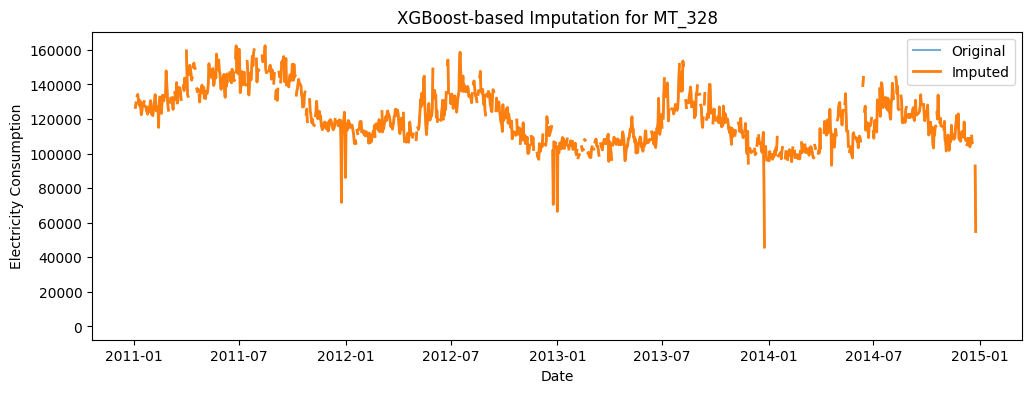

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(ts, label="Original", alpha=0.6)
plt.plot(ts_imputed, label="Imputed", linewidth=2)
plt.legend()
plt.title("XGBoost-based Imputation for MT_328")
plt.xlabel("Date")
plt.ylabel("Electricity Consumption")
plt.show()


In [ ]:
mask = y_train.sample(frac=0.2, random_state=42).index

X_val = X_train.loc[mask]
y_val = y_train.loc[mask]

y_hat = xgb_model.predict(X_val)

rmse = root_mean_squared_error(y_val, y_hat)
rmse


358.45945360885656

In [ ]:
def impute_series_xgb(series):
    df_feat = create_time_features(series)

    train = df_feat.dropna()
    train = train[train["y"].notna()]

    X_train = train.drop(columns="y")
    y_train = train["y"]

    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    model.fit(X_train, y_train)

    missing = df_feat[df_feat["y"].isna()]
    X_missing = missing.drop(columns="y").dropna()

    series_imputed = series.copy()
    series_imputed.loc[X_missing.index] = model.predict(X_missing)

    return series_imputed


In [ ]:
df_imputed = pd.DataFrame(
    {col: impute_series_xgb(df_50[col]) for col in df_50.columns}
)


In [ ]:
df_imputed.isna().sum().sum()


np.int64(9813)

In [ ]:
df_imputed_clean = df_imputed.dropna()


In [ ]:
df_imputed_clean.isna().sum().sum()


np.int64(0)

In [ ]:
features = pd.DataFrame(index=df_imputed_clean.columns)


In [ ]:
features["mean_consumption"] = df_imputed_clean.mean()


In [ ]:
features["std_consumption"] = df_imputed_clean.std()


In [ ]:
features["peak_to_avg"] = (
    df_imputed_clean.max() / df_imputed_clean.mean()
)


In [ ]:
weekday_mean = df_imputed_clean[df_imputed_clean.index.weekday < 5].mean()
weekend_mean = df_imputed_clean[df_imputed_clean.index.weekday >= 5].mean()

features["weekday_weekend_ratio"] = weekday_mean / weekend_mean


In [ ]:
monthly_mean = df_imputed_clean.groupby(df_imputed_clean.index.month).mean()

features["seasonal_amplitude"] = (
    monthly_mean.max() - monthly_mean.min()
)


In [ ]:
features.head()
features.describe()


,mean_consumption,std_consumption,peak_to_avg,weekday_weekend_ratio,seasonal_amplitude
count,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN


In [ ]:
features_new = pd.DataFrame(index=df_imputed_clean.index)  # index = customers

# 2. Mean consumption (baseline demand)
features_new["mean_consumption"] = df_imputed_clean.mean(axis=1)

# 3. Standard deviation (volatility)
features_new["std_consumption"] = df_imputed_clean.std(axis=1)

# 4. Peak-to-Average Ratio
features_new["peak_to_avg"] = df_imputed_clean.max(axis=1) / df_imputed_clean.mean(axis=1)

# 5. Weekday vs Weekend Ratio
weekday_mean = df_imputed_clean[df_imputed_clean.index.weekday < 5].mean(axis=1)
weekend_mean = df_imputed_clean[df_imputed_clean.index.weekday >= 5].mean(axis=1)
features_new["weekday_weekend_ratio"] = weekday_mean / weekend_mean

# 6. Seasonal Amplitude (annual pattern)
monthly_mean = df_imputed_clean.groupby(df_imputed_clean.index.month).mean()
features_new["seasonal_amplitude"] = monthly_mean.max(axis=0) - monthly_mean.min(axis=0)


In [ ]:
features_new.head()
features_new.describe()


,mean_consumption,std_consumption,peak_to_avg,weekday_weekend_ratio,seasonal_amplitude
count,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_imputed_clean.shape
df_imputed_clean.head()


,MT_328,MT_034,MT_016,MT_315,MT_058,MT_240,MT_077,MT_120,MT_306,MT_127,...,MT_250,MT_298,MT_031,MT_220,MT_110,MT_125,MT_091,MT_057,MT_006,MT_046
data,,,,,,,,,,,,,,,,,,,,,


In [ ]:
features = pd.DataFrame(index=df_imputed_clean.index)  # index = customers

# 1. Mean consumption
features["mean_consumption"] = df_imputed_clean.mean(axis=1)

# 2. Standard deviation
features["std_consumption"] = df_imputed_clean.std(axis=1)

# 3. Peak-to-average ratio
features["peak_to_avg"] = df_imputed_clean.max(axis=1) / df_imputed_clean.mean(axis=1)

# 4. Weekday vs weekend ratio (only if index is datetime)
if isinstance(df_imputed_clean.index, pd.DatetimeIndex):
    weekday_mean = df_imputed_clean[df_imputed_clean.index.weekday < 5].mean(axis=1)
    weekend_mean = df_imputed_clean[df_imputed_clean.index.weekday >= 5].mean(axis=1)
    features["weekday_weekend_ratio"] = weekday_mean / weekend_mean

# 5. Seasonal amplitude (monthly)
if isinstance(df_imputed_clean.index, pd.DatetimeIndex):
    monthly_mean = df_imputed_clean.groupby(df_imputed_clean.index.month).mean()
    # Take max-min across months per customer
    features["seasonal_amplitude"] = monthly_mean.max() - monthly_mean.min()


In [ ]:
features.head()
features.describe()


,mean_consumption,std_consumption,peak_to_avg,weekday_weekend_ratio,seasonal_amplitude
count,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_imputed_clean.shape
df_imputed_clean.head()


,MT_328,MT_034,MT_016,MT_315,MT_058,MT_240,MT_077,MT_120,MT_306,MT_127,...,MT_250,MT_298,MT_031,MT_220,MT_110,MT_125,MT_091,MT_057,MT_006,MT_046
data,,,,,,,,,,,,,,,,,,,,,


In [ ]:
# Example: assume df_raw is your starting data
df_imputed_clean = df.fillna(method='ffill')  # simple imputation
print(df_imputed_clean.shape)


(1462, 50)


/tmp/ipython-input-3436073309.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_imputed_clean = df.fillna(method='ffill')  # simple imputation


In [ ]:
print(df_imputed_clean.shape)
print(df_imputed_clean.isna().sum().sum())

(1462, 50)
7


In [ ]:
features = pd.DataFrame(index=df_imputed_clean.index)

features["mean_consumption"] = df_imputed_clean.mean(axis=1)
features["std_consumption"] = df_imputed_clean.std(axis=1)
features["peak_to_avg"] = df_imputed_clean.max(axis=1) / df_imputed_clean.mean(axis=1)


In [ ]:
features.head()
features.describe()

,mean_consumption,std_consumption,peak_to_avg
count,1462.000000,1462.000000,1462.000000
mean,52089.375566,169979.147184,22.318554
std,5031.158392,19664.938517,2.837219
min,20960.829369,42815.652687,11.485094
25%,49154.368527,155430.173685,20.488517
50%,51533.184359,168517.050539,21.125024
75%,54967.876096,181926.929041,23.388966
max,68265.567496,219747.729886,47.935404


In [ ]:
import pandas as pd

# 1️⃣ Impute missing values (simple forward fill)
df_imputed_clean = df.fillna(method='ffill')  # or choose your preferred method
print(df_imputed_clean.shape)  # sanity check

# 2️⃣ Initialize features table
features = pd.DataFrame(index=df_imputed_clean.index)

# 3️⃣ Mean consumption (baseline demand)
features["mean_consumption"] = df_imputed_clean.mean(axis=1)

# 4️⃣ Standard deviation (volatility)
features["std_consumption"] = df_imputed_clean.std(axis=1)

# 5️⃣ Peak-to-Average Ratio (load spikes)
features["peak_to_avg"] = df_imputed_clean.max(axis=1) / df_imputed_clean.mean(axis=1)

# 6️⃣ Optional: Weekday vs Weekend Ratio (if index is datetime)
if isinstance(df_imputed_clean.index, pd.DatetimeIndex):
    weekday_mean = df_imputed_clean[df_imputed_clean.index.weekday < 5].mean(axis=1)
    weekend_mean = df_imputed_clean[df_imputed_clean.index.weekday >= 5].mean(axis=1)
    features["weekday_weekend_ratio"] = weekday_mean / weekend_mean

# 7️⃣ Optional: Seasonal amplitude (monthly)
if isinstance(df_imputed_clean.index, pd.DatetimeIndex):
    monthly_mean = df_imputed_clean.groupby(df_imputed_clean.index.month).mean()
    features["seasonal_amplitude"] = monthly_mean.max() - monthly_mean.min()

(1462, 50)


/tmp/ipython-input-739995089.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_imputed_clean = df.fillna(method='ffill')  # or choose your preferred method


In [ ]:
print(features.head())
print(features.describe())

            mean_consumption  std_consumption  peak_to_avg  \
data                                                         
2011-01-01      33041.566269    155940.011541    30.831468   
2011-01-02      46322.748604    188409.513590    27.671214   
2011-01-03      46793.364767    184405.979394    26.699102   
2011-01-04      47287.098081    187969.739917    26.991682   
2011-01-05      47344.306226    189368.224051    27.164020   

            weekday_weekend_ratio  seasonal_amplitude  
data                                                   
2011-01-01                    NaN                 NaN  
2011-01-02                    NaN                 NaN  
2011-01-03                    NaN                 NaN  
2011-01-04                    NaN                 NaN  
2011-01-05                    NaN                 NaN  
       mean_consumption  std_consumption  peak_to_avg  weekday_weekend_ratio  \
count       1462.000000      1462.000000  1462.000000                    0.0   
mean       52

In [ ]:
df_customers = df.T  # now rows = customers, columns = daily usage


In [ ]:
features = pd.DataFrame(index=df_customers.index)

# 1. Mean consumption
features["mean_consumption"] = df_customers.mean(axis=1)

# 2. Standard deviation
features["std_consumption"] = df_customers.std(axis=1)

# 3. Peak-to-Average ratio
features["peak_to_avg"] = df_customers.max(axis=1) / df_customers.mean(axis=1)

# 4. Weekday vs Weekend ratio
# Only works if columns are datetime index
df_customers.columns = pd.to_datetime(df_customers.columns)  # ensure datetime
weekday_mean = df_customers.loc[:, df_customers.columns.weekday < 5].mean(axis=1)
weekend_mean = df_customers.loc[:, df_customers.columns.weekday >= 5].mean(axis=1)
features["weekday_weekend_ratio"] = weekday_mean / weekend_mean

# 5. Seasonal amplitude (monthly)
monthly_mean = df_customers.groupby(df_customers.columns.month, axis=1).mean()
features["seasonal_amplitude"] = monthly_mean.max(axis=1) - monthly_mean.min(axis=1)

# Sanity check
print(features.head())
print(features.describe())


        mean_consumption  std_consumption  peak_to_avg  weekday_weekend_ratio  \
MT_328     120541.560438     15920.365358     1.347315               0.993953   
MT_034       1008.392159       615.622111     2.253435               0.903040   
MT_016       2383.878650      1447.177024     2.353031               0.918078   
MT_315       8526.267931      1139.012426     1.454841               0.991278   
MT_058       6207.692348      3685.050456     2.053706               0.914226   

        seasonal_amplitude  
MT_328        29843.208461  
MT_034          382.975345  
MT_016          831.906889  
MT_315         2531.284996  
MT_058         2291.949011  
       mean_consumption  std_consumption  peak_to_avg  weekday_weekend_ratio  \
count      5.000000e+01        50.000000    50.000000              50.000000   
mean       5.209342e+04     11760.422241     2.639697               1.106475   
std        1.691321e+05     23012.598899     2.060101               0.481807   
min        3.901470

/tmp/ipython-input-2251569906.py:20: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  monthly_mean = df_customers.groupby(df_customers.columns.month, axis=1).mean()


In [ ]:
from sklearn.preprocessing import StandardScaler

# Select features for clustering
X = features.copy()  # using all engineered features

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Quick sanity check
print(pd.DataFrame(X_scaled, index=features.index, columns=features.columns).head())


        mean_consumption  std_consumption  peak_to_avg  weekday_weekend_ratio  \
MT_328          0.408811         0.182603    -0.633708              -0.235913   
MT_034         -0.305109        -0.489208    -0.189400              -0.426520   
MT_016         -0.296894        -0.452706    -0.140564              -0.394992   
MT_315         -0.260208        -0.466233    -0.580984              -0.241522   
MT_058         -0.274056        -0.354474    -0.287335              -0.403067   

        seasonal_amplitude  
MT_328            0.550415  
MT_034           -0.395383  
MT_016           -0.380970  
MT_315           -0.326413  
MT_058           -0.334097  


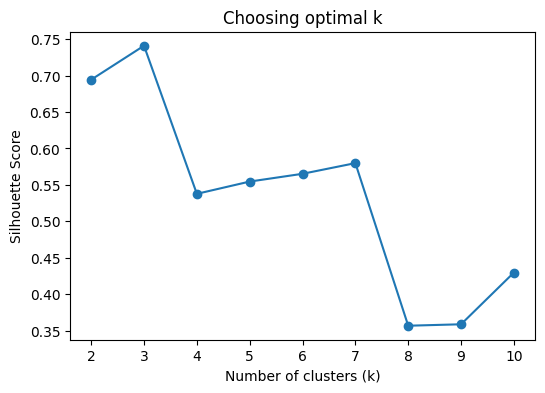

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

sil_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

# Plot Silhouette Score vs k
plt.figure(figsize=(6,4))
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Choosing optimal k')
plt.show()


In [ ]:
optimal_k = K_range[sil_scores.index(max(sil_scores))]
print(f"Optimal k = {optimal_k}")

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to features
features["cluster"] = cluster_labels

# Quick view
print(features.groupby("cluster").mean())


Optimal k = 3
         mean_consumption  std_consumption  peak_to_avg  \
cluster                                                   
0            3.011611e+04      9397.768797     2.667238   
1            1.155080e+06    132433.781999     1.285877   
2            4.017720e+03      4494.427802     2.671567   

         weekday_weekend_ratio  seasonal_amplitude  
cluster                                             
0                     1.043786         9070.016048  
1                     0.991946       195494.476372  
2                     4.230085         4074.002327  


In [ ]:
# df = original data, rows = dates, columns = customers
df_customers = df.T  # rows = customers, columns = daily timestamps

# Create lag features for each customer
def create_lag_features(series, lags=[1,2,7,14]):
    df_lags = pd.DataFrame(series)
    for lag in lags:
        df_lags[f'lag_{lag}'] = series.shift(lag)
    return df_lags

# Example for one customer
cust_id = df_customers.index[0]
y = df_customers.loc[cust_id]
X_lagged = create_lag_features(y)
print(X_lagged.head(10))

                   MT_328          lag_1          lag_2          lag_7  lag_14
data                                                                          
2011-01-01   66992.592593            NaN            NaN            NaN     NaN
2011-01-02            NaN   66992.592593            NaN            NaN     NaN
2011-01-03  126733.333333            NaN   66992.592593            NaN     NaN
2011-01-04  129348.148148  126733.333333            NaN            NaN     NaN
2011-01-05            NaN  129348.148148  126733.333333            NaN     NaN
2011-01-06  133488.888889            NaN  129348.148148            NaN     NaN
2011-01-07  134192.592593  133488.888889            NaN            NaN     NaN
2011-01-08  131570.370370  134192.592593  133488.888889   66992.592593     NaN
2011-01-09  128496.296296  131570.370370  134192.592593            NaN     NaN
2011-01-10  127725.925926  128496.296296  131570.370370  126733.333333     NaN


In [ ]:
from sklearn.model_selection import train_test_split

# Drop rows where target is NaN
X = X_lagged.drop(columns=[y.name])
y_target = y
mask = ~y_target.isna()
X_train = X[mask]
y_train = y_target[mask]

# Train XGBoost
model = xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
X_missing = X[~mask]  # lag features where target is missing
y_pred = model.predict(X_missing)

# Fill back into original series
y_imputed = y.copy()
y_imputed[~mask] = y_pred


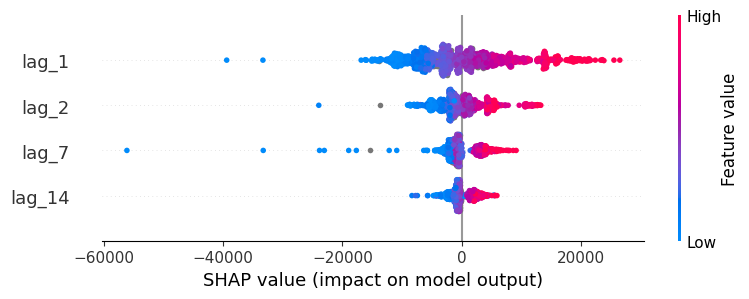

In [ ]:
import shap

explainer = shap.Explainer(model)
shap_values = explainer(X_train)

# Global summary
shap.summary_plot(shap_values, X_train)


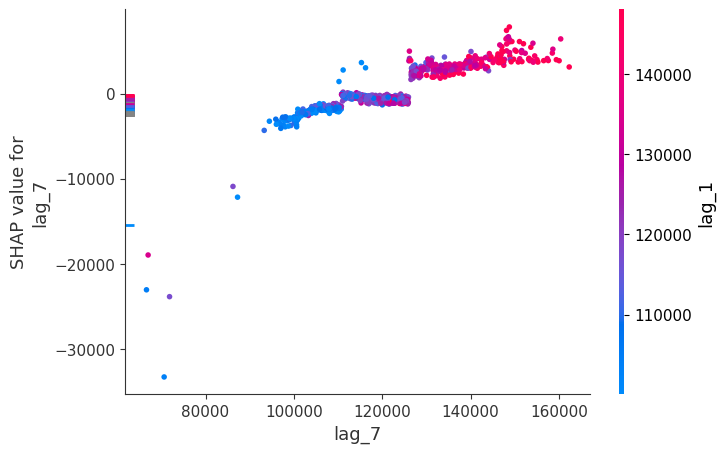

In [ ]:
shap.dependence_plot("lag_7", shap_values.values, X_train)


In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# Features and target
X = X_scaled  # standardized features
y = features["cluster"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost classifier
clf = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
clf.fit(X_train, y_train)

# Optional: evaluate accuracy
print("Surrogate classifier accuracy:", clf.score(X_test, y_test))


Surrogate classifier accuracy: 1.0


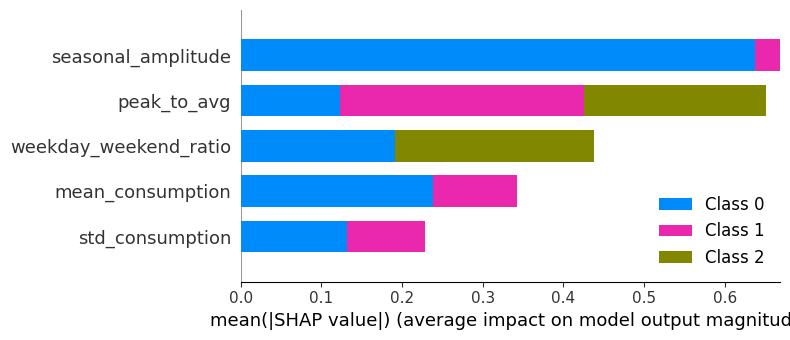

In [ ]:
import shap

# SHAP explainer
explainer = shap.Explainer(clf, X_train)
shap_values = explainer(X_train)

# Global feature importance
shap.summary_plot(shap_values, X_train, feature_names=features.columns[:-1])


In [ ]:
# shap_values.values shape = (n_samples, n_features, n_classes)
# Take mean absolute value across classes
shap_values_2d = np.mean(np.abs(shap_values.values), axis=2)  # shape -> (n_samples, n_features)

# Create DataFrame
shap_df = pd.DataFrame(shap_values_2d, columns=features.columns[:-1])  # exclude 'cluster'
shap_df["cluster"] = y_train.values

# Mean SHAP per cluster
cluster_shap = shap_df.groupby("cluster").mean()
print(cluster_shap)

         mean_consumption  std_consumption  peak_to_avg  \
cluster                                                   
0                0.111400         0.069429     0.206176   
1                0.199148         0.324522     0.647474   
2                0.126681         0.083073     0.206985   

         weekday_weekend_ratio  seasonal_amplitude  
cluster                                             
0                     0.128581            0.212438  
1                     0.083412            0.456288  
2                     0.864403            0.384821  


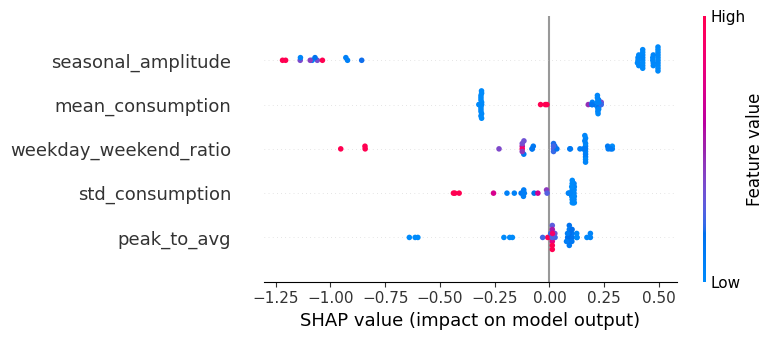

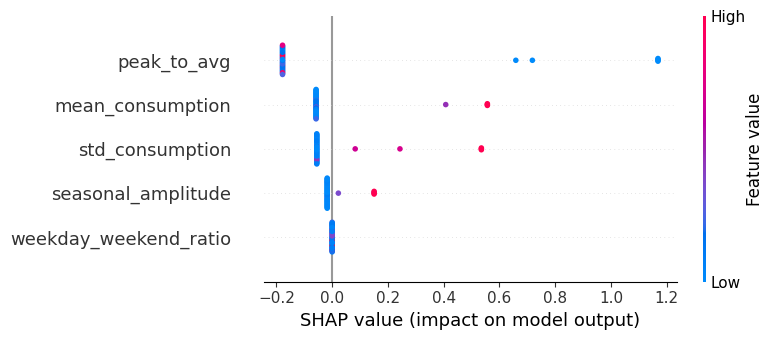

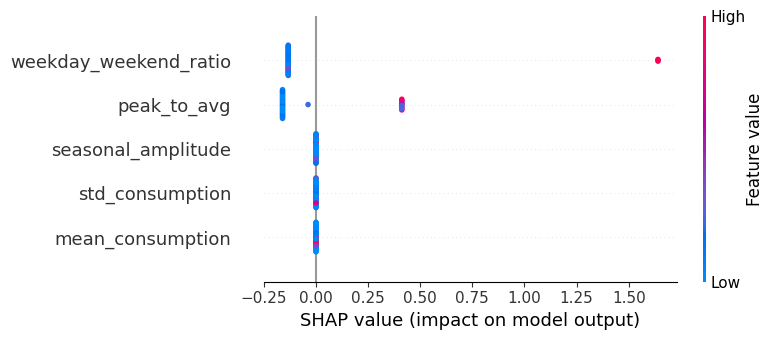

In [ ]:
# If you want per-class summary
for i, cls in enumerate(clf.classes_):
    shap.summary_plot(shap_values.values[:,:,i], X_train, feature_names=features.columns[:-1], show=True)


In [ ]:
explainer = shap.Explainer(clf, X_train)
shap_values = explainer(X_train)

# shap_values.values shape = (n_samples, n_features, n_classes)
# Take mean absolute across classes to summarize
shap_values_2d = np.mean(np.abs(shap_values.values), axis=2)  # shape -> (n_samples, n_features)

# Create DataFrame
shap_df = pd.DataFrame(shap_values_2d, columns=features.columns[:-1])
shap_df["cluster"] = y_train.values

# Compute mean SHAP per cluster
cluster_shap = shap_df.groupby("cluster").mean()
print("Mean SHAP per cluster:")
print(cluster_shap)

Mean SHAP per cluster:
         mean_consumption  std_consumption  peak_to_avg  \
cluster                                                   
0                0.111400         0.069429     0.206176   
1                0.199148         0.324522     0.647474   
2                0.126681         0.083073     0.206985   

         weekday_weekend_ratio  seasonal_amplitude  
cluster                                             
0                     0.128581            0.212438  
1                     0.083412            0.456288  
2                     0.864403            0.384821  


SHAP Summary for Cluster 0:


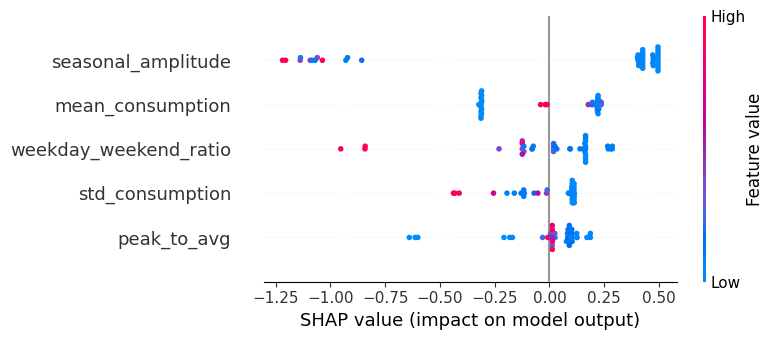

SHAP Summary for Cluster 1:


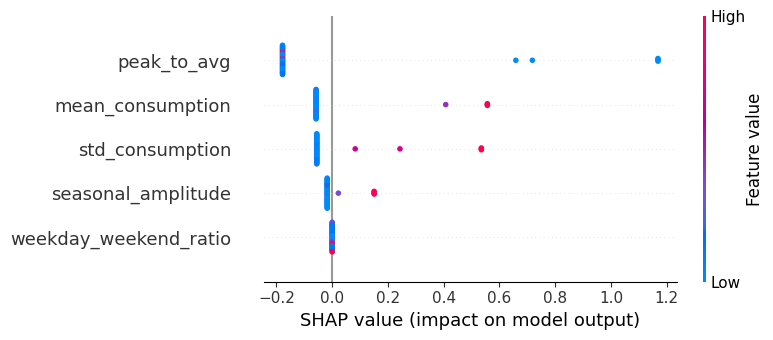

SHAP Summary for Cluster 2:


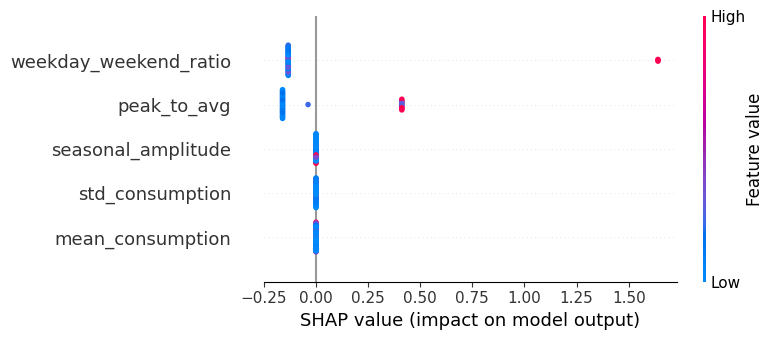

In [ ]:
for i, cls in enumerate(clf.classes_):
    print(f"SHAP Summary for Cluster {cls}:")
    shap.summary_plot(shap_values.values[:,:,i], X_train, feature_names=features.columns[:-1])


Dependence plot for mean_consumption in Cluster 0:


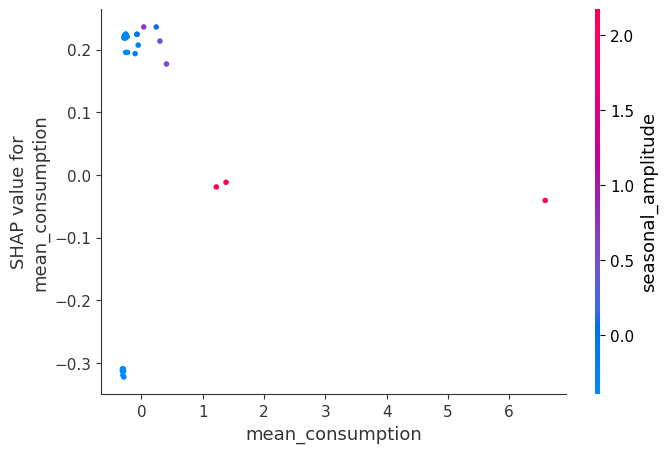

Dependence plot for mean_consumption in Cluster 1:


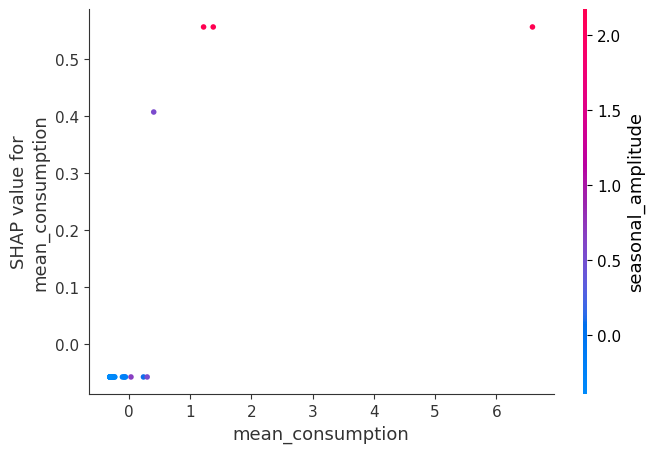

Dependence plot for mean_consumption in Cluster 2:


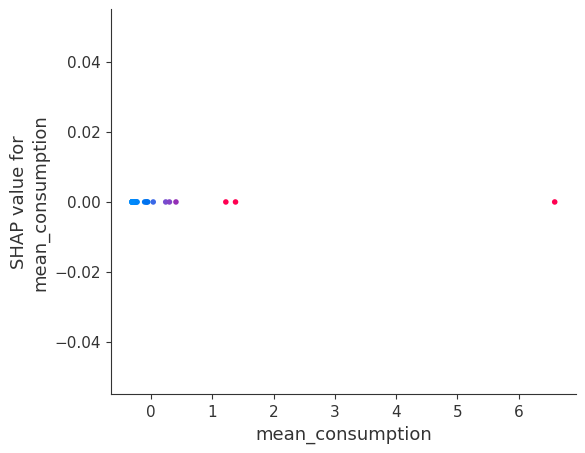

In [ ]:
# Example: How mean_consumption drives cluster assignment
feature_to_plot = "mean_consumption"
for i, cls in enumerate(clf.classes_):
    print(f"Dependence plot for {feature_to_plot} in Cluster {cls}:")
    shap.dependence_plot(feature_to_plot, shap_values.values[:,:,i], X_train,
                         feature_names=features.columns[:-1])
